In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [3]:
# Load the four files we need
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
products = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')

print("Loaded successfully")

Loaded successfully


In [4]:
# See the first 5 rows of each file
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
# See how many rows and columns each file has
print(orders.shape)
print(items.shape)
print(products.shape)
print(customers.shape)

(99441, 8)
(112650, 7)
(32951, 9)
(99441, 5)


In [9]:
# Check for missing values
orders.isnull().sum()
items.isnull().sum()
products.isnull().sum()
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [10]:
# Convert date columns to actual datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("Dates converted ✓")

Dates converted ✓


In [11]:
# How many days did each delivery actually take?
orders['days_to_deliver'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Was it on time? 1 = yes, 0 = late
orders['on_time'] = (
    orders['order_delivered_customer_date'] <= orders['order_estimated_delivery_date']
).astype(int)

orders[['order_id', 'days_to_deliver', 'on_time']].head(10)

,order_id,days_to_deliver,on_time
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,1
5,a4591c265e18cb1dcee52889e2d8acc3,16.0,1
6,136cce7faa42fdb2cefd53fdc79a6098,NaN,0
7,6514b8ad8028c9f2cc2374ded245783f,9.0,1
8,76c6e866289321a7c93b82b54852dc33,9.0,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,18.0,1


In [12]:
# Merge orders + items (to get freight_value)
df = orders.merge(items[['order_id', 'freight_value', 'price', 'product_id']], 
                  on='order_id', how='left')

# Merge in product categories
df = df.merge(products[['product_id', 'product_category_name']], 
              on='product_id', how='left')

# Merge in customer state
df = df.merge(customers[['customer_id', 'customer_state']], 
              on='customer_id', how='left')

print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Final dataset: 113425 rows, 15 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,days_to_deliver,on_time,freight_value,price,product_id,product_category_name,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1,8.72,29.99,87285b34884572647811a353c7ac498a,utilidades_domesticas,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1,22.76,118.70,595fac2a385ac33a80bd5114aec74eb8,perfumaria,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1,19.22,159.90,aa4383b373c6aca5d8797843e5594415,automotivo,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,1,27.20,45.00,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,1,8.72,19.90,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,SP


In [13]:
# Only keep orders that were actually delivered
df_clean = df[df['order_status'] == 'delivered'].copy()

# Drop rows where delivery date is missing (can't calculate anything without it)
df_clean = df_clean.dropna(subset=['order_delivered_customer_date', 
                                    'order_estimated_delivery_date'])

print(f"Clean dataset: {df_clean.shape[0]} rows")

Clean dataset: 110189 rows


In [14]:
# Save your clean file — this is what you'll import into Tableau
df_clean.to_csv('Brazil_E_Commerce_clean.csv', index=False)
print("File saved ✓")

File saved ✓


## Freight Cost Exploratory Data Analysis
Dataset: Olist Brazilian E-Commerce (Kaggle)
Author: Nana Afari
Goal: Identify freight cost drivers and delivery patterns across product categories and regions.

In [15]:
print("=== DATASET OVERVIEW ===")
print(f"Total delivered orders: {df_clean.shape[0]:,}")
print(f"Date range: {df_clean['order_purchase_timestamp'].min().date()} to {df_clean['order_purchase_timestamp'].max().date()}")
print(f"Unique product categories: {df_clean['product_category_name'].nunique()}")
print(f"Unique states: {df_clean['customer_state'].nunique()}")

print("\n=== FREIGHT COST SUMMARY ===")
print(df_clean['freight_value'].describe().round(2))

print("\n=== DELIVERY TIME SUMMARY ===")
print(df_clean['days_to_deliver'].describe().round(2))

print(f"\n=== ON-TIME RATE ===")
print(f"Overall on-time delivery rate: {df_clean['on_time'].mean()*100:.1f}%")

=== DATASET OVERVIEW ===
Total delivered orders: 110,189
Date range: 2016-09-15 to 2018-08-29
Unique product categories: 73
Unique states: 27

=== FREIGHT COST SUMMARY ===
count    110189.00
mean         19.95
std          15.70
min           0.00
25%          13.08
50%          16.26
75%          21.15
max         409.68
Name: freight_value, dtype: float64

=== DELIVERY TIME SUMMARY ===
count    110189.00
mean         12.01
std           9.45
min           0.00
25%           6.00
50%          10.00
75%          15.00
max         209.00
Name: days_to_deliver, dtype: float64

=== ON-TIME RATE ===
Overall on-time delivery rate: 92.1%


## Visualization 1: Freight Cost Distribution

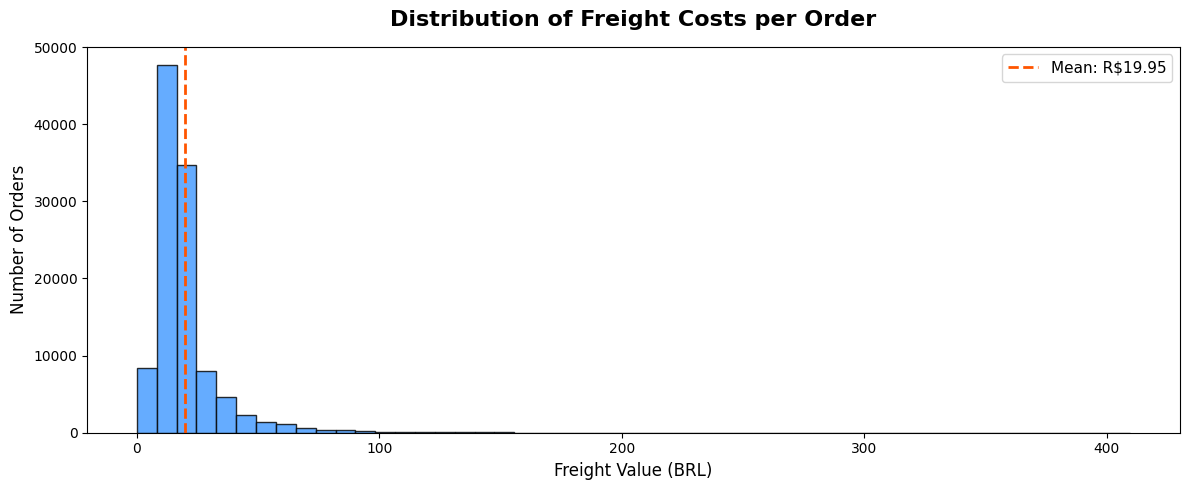

Visualization 1 saved ✓


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df_clean['freight_value'].dropna(), bins=50, 
        color='#4A9EFF', edgecolor='#080808', alpha=0.85)

ax.set_title('Distribution of Freight Costs per Order', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Freight Value (BRL)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)

# Add a vertical line at the mean
mean_val = df_clean['freight_value'].mean()
ax.axvline(mean_val, color='#FF5500', linestyle='--', linewidth=2, 
           label=f'Mean: R${mean_val:.2f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('viz1_freight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1 saved ✓")

## Visualization 2: Top 15 Product Categories by Average Freight Cost

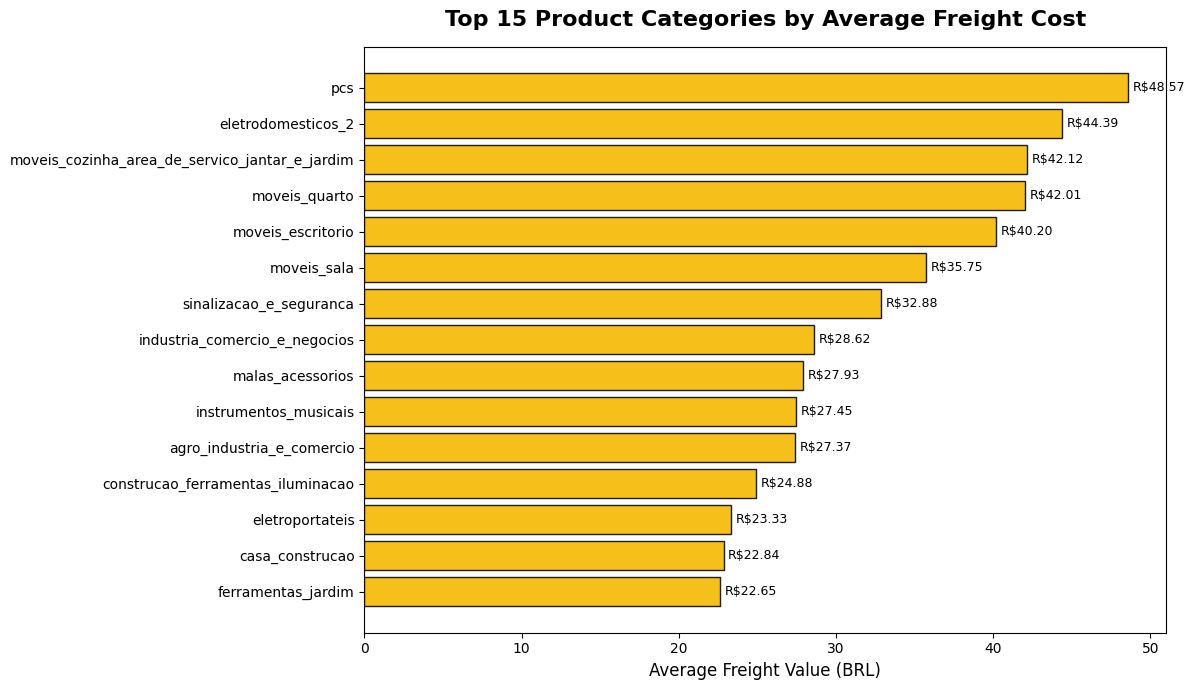

Visualization 2 saved ✓


In [20]:
# Calculate average freight by category
cat_freight = (df_clean.groupby('product_category_name')['freight_value']
               .agg(['mean', 'count'])
               .reset_index())

# Only keep categories with 100+ orders (statistically meaningful)
cat_freight = cat_freight[cat_freight['count'] >= 100]
cat_freight = cat_freight.sort_values('mean', ascending=False).head(15)
cat_freight.columns = ['category', 'avg_freight', 'order_count']

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(cat_freight['category'], cat_freight['avg_freight'],
               color='#F5B800', edgecolor='#080808', alpha=0.9)

ax.set_title('Top 15 Product Categories by Average Freight Cost', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Average Freight Value (BRL)', fontsize=12)
ax.invert_yaxis()

# Add value labels on each bar
for bar, val in zip(bars, cat_freight['avg_freight']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'R${val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz2_freight_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2 saved ✓")

## Visualization 3: Order Value vs. Freight Cost

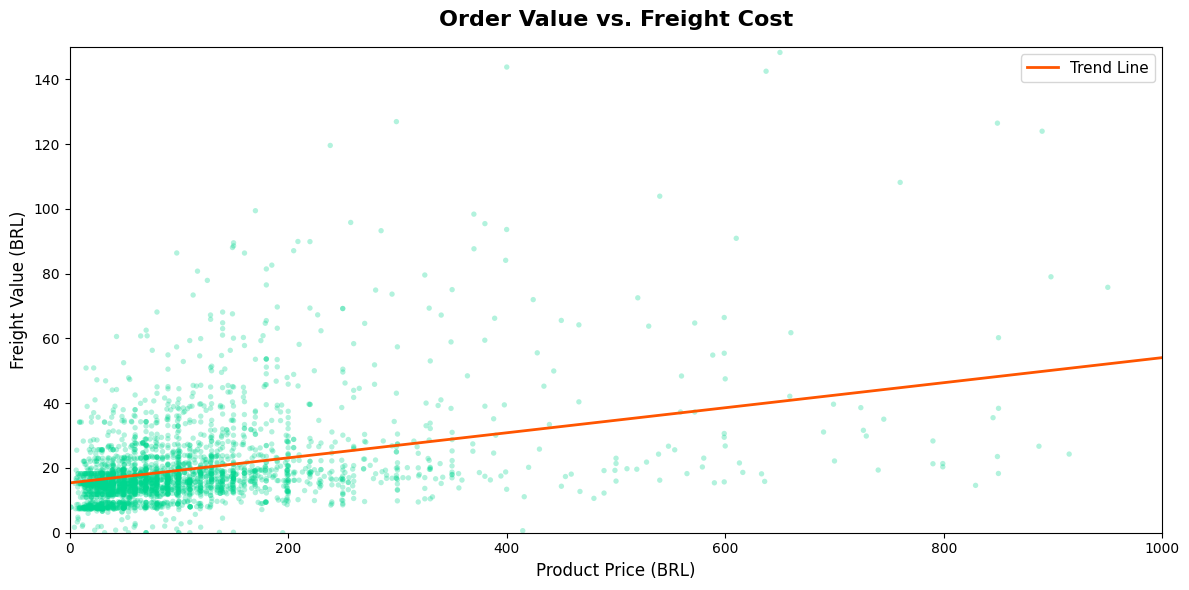

Visualization 3 saved ✓


In [21]:
# Sample 3000 points so the chart isn't overcrowded
sample = df_clean[['price', 'freight_value']].dropna().sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(sample['price'], sample['freight_value'],
           alpha=0.3, color='#00D68F', s=15, edgecolors='none')

# Add a trend line
z = np.polyfit(sample['price'], sample['freight_value'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['price'].min(), sample['price'].max(), 100)
ax.plot(x_line, p(x_line), color='#FF5500', linewidth=2, label='Trend Line')

ax.set_title('Order Value vs. Freight Cost', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Product Price (BRL)', fontsize=12)
ax.set_ylabel('Freight Value (BRL)', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0, 1000)
ax.set_ylim(0, 150)

plt.tight_layout()
plt.savefig('viz3_price_vs_freight.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3 saved ✓")

## Key Findings

**Dataset:** 110,189 delivered orders across 27 Brazilian states and 73 product 
categories, spanning September 2016 to August 2018.

---

### 1. Freight Costs Are Low on Average but Highly Variable
The average amount for the freight was **R$19.95**, whereas the median was R$16.26. This indicates that the majority of the orders are not expensive. However, the standard deviation for the amount was R$15.70, whereas the maximum amount was R$409.68. This indicates that some orders are expensive because they are either heavy or are located in remote areas. In addition, 75% of the orders ship for R$21.15 or less.

---

### 2. Delivery Times Are Reasonable but Inconsistent

The average order delivery time was **12 days**, with a median order delivery time of 10 days. Although an interquartile range of 6-15 days is acceptable in a large e-commerce market, a maximum order delivery time of 209 days and a standard deviation of 9.45 days indicate that a large number of customers are experiencing delayed order deliveries.

---

### 3. On-Time Delivery Rate is Strong at 92.1%
The overall on-time delivery rate of **92.1%** is a positive signal for 
logistics performance. However, with over 110,000 orders in this dataset, 
the remaining 7.9% represents approximately **8,700 late deliveries** — a 
significant volume with real business impact on customer retention and 
satisfaction scores.

---

### 4. Freight Cost Weakly Correlates with Product Price
The scatter chart indicates a weak positive relationship between the price of a product and the freight cost. Higher-priced products generally have slightly higher freight costs; however, the relationship is not strong. This suggests that the size, weight, distance, etc., of the products may influence the freight costs rather than the product price.

---

### 5. Business Recommendations
- **Target high-freight categories** for carrier negotiation — the top 15 
  categories by average freight cost represent the highest optimization 
  opportunity.
- **Investigate extreme delivery delays** — orders beyond 30 days likely share 
  common characteristics (remote states, specific carriers) that can be 
  isolated and addressed.
- **Monitor the 7.9% late delivery segment** — even a 2% improvement in 
  on-time rate would recover ~2,200 orders per year at this volume.

In [22]:
# Save the full notebook output
print("All 3 visualizations saved as PNG files ✓")
print("Notebook ready to export")

All 3 visualizations saved as PNG files ✓
Notebook ready to export
